In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator


In [2]:
# Load the image
image = cv2.imread('data/pedestrian_day.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [3]:
# Load the model
# Path to the checkpoint
sam_checkpoint = "data/sam_vit_h_4b8939.pth"
model_type = "vit_h"

# Device to run the model on
device="cpu"

# Load the model
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

# Create the predictor
mask_generator = SamAutomaticMaskGenerator(sam)


In [4]:
# Generate the mask
# This will take a few seconds
masks = mask_generator.generate(image)

In [5]:
# print the results
print(len(masks))
print(masks[0].keys())

87
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


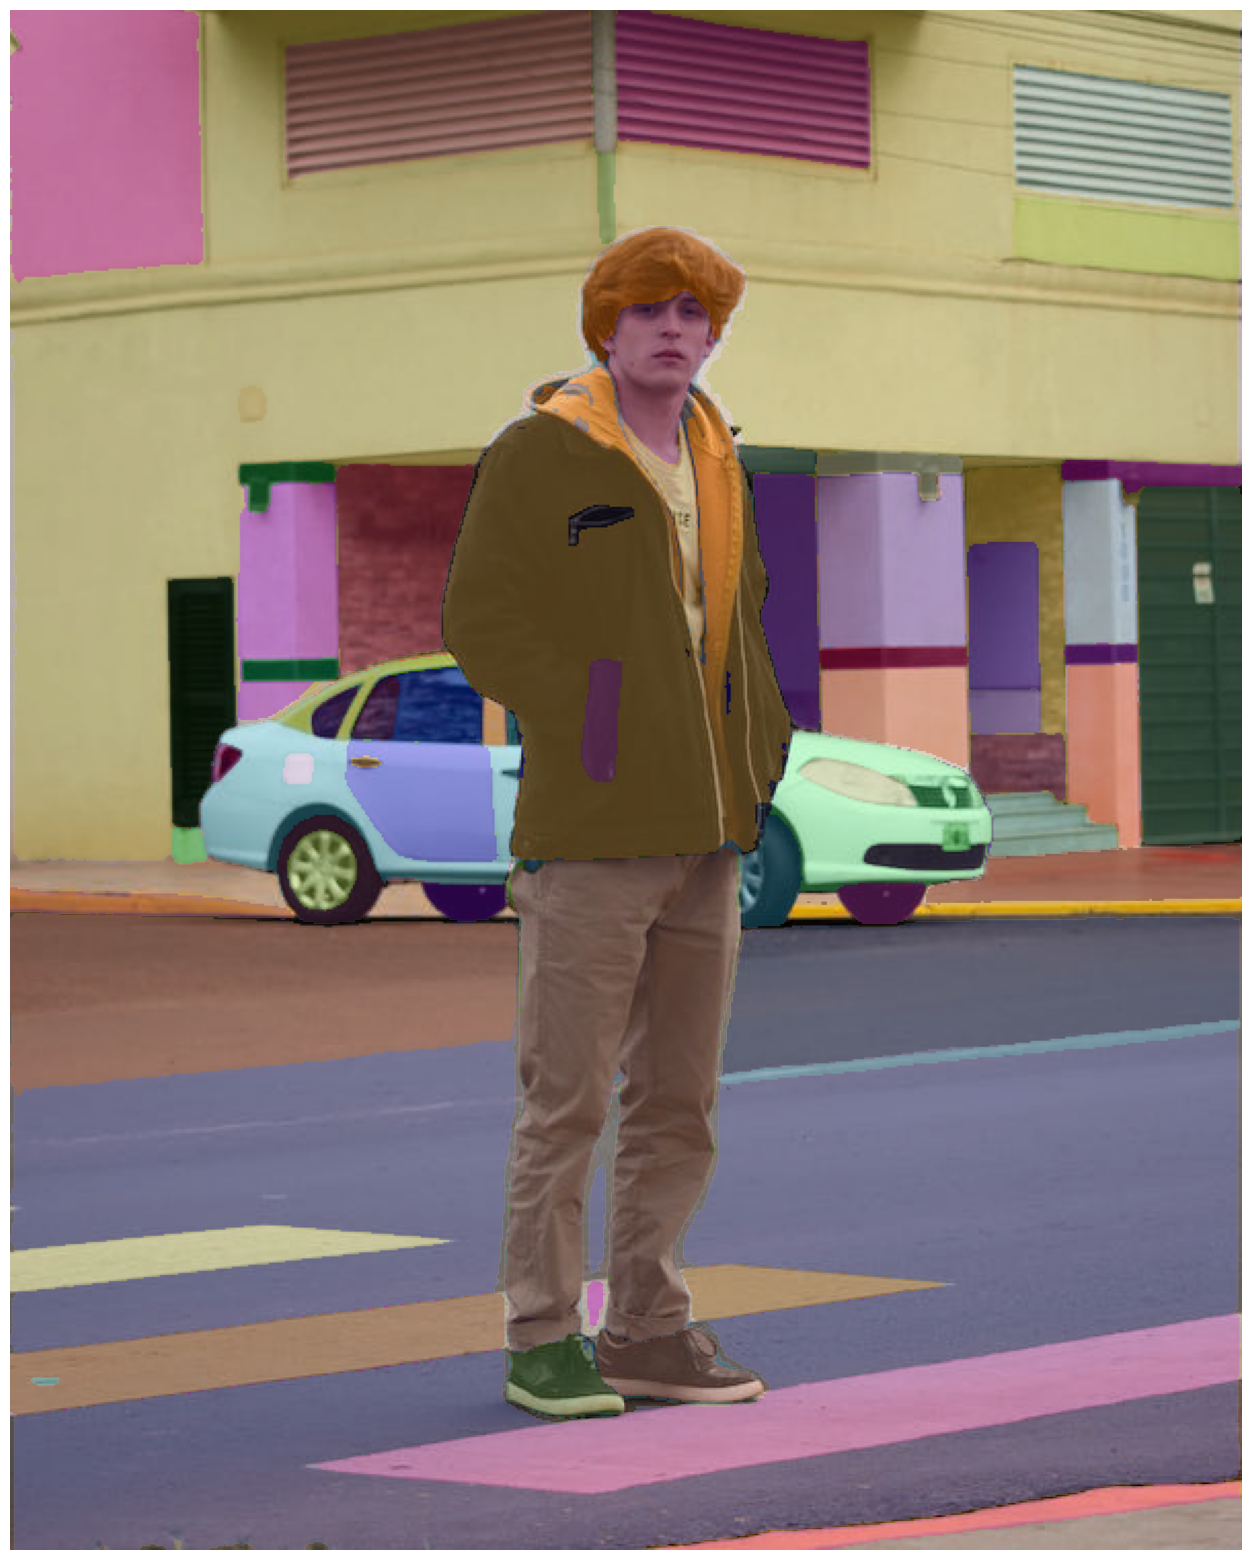

In [6]:
# Function to display segmentation masks
def show_anns(anns, ax):

    # Return if no annotations
    if len(anns) == 0:
        return

    # Sort annotations by area
    sorted_anns = sorted(anns, key=lambda x: x['area'], reverse=True)

    # Disable autoscaling
    ax.set_autoscale_on(False)

    # Create transparent image based on first annotation's segmentation shape
    img = np.ones(
        (
            sorted_anns[0]['segmentation'].shape[0],
            sorted_anns[0]['segmentation'].shape[1],
            4
        )
    )

    img[:, :, 3] = 0

    # For each annotation
    for ann in sorted_anns:

        # Get segmentation mask
        m = ann['segmentation']

        # Create color mask
        color_mask = np.concatenate(
            [np.random.random(3), [0.35]]
        )

        # Apply color mask
        img[m] = color_mask

    # Display image
    ax.imshow(img)


plt.figure(figsize=(20,20))
plt.imshow(image)

show_anns(masks, plt.gca())

plt.axis('off')
plt.show()

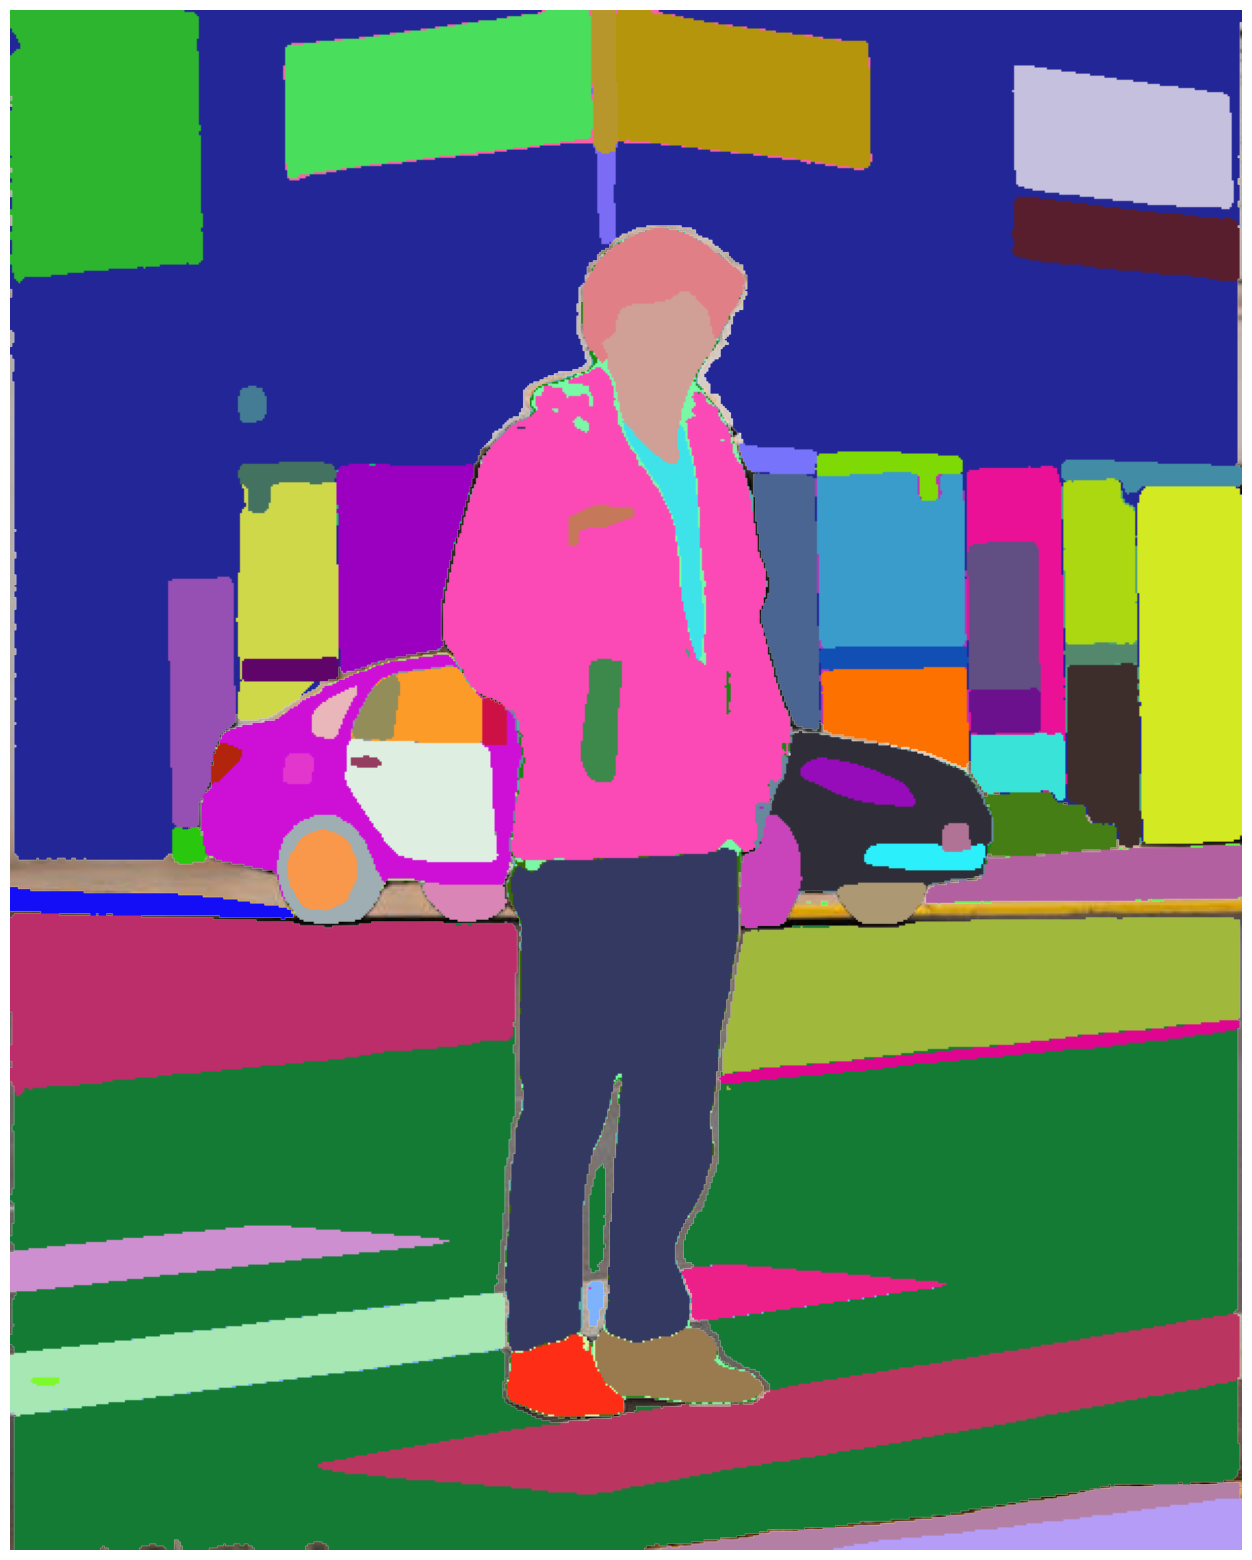

In [7]:
import numpy as np

def show_anns_full(anns, ax):
    if len(anns) == 0:
        return

    sorted_anns = sorted(anns, key=lambda x: x["area"], reverse=True)

    ax.set_autoscale_on(False)

    img = np.ones((
        sorted_anns[0]["segmentation"].shape[0],
        sorted_anns[0]["segmentation"].shape[1],
        4
    ))

    img[:, :, 3] = 0

    for ann in sorted_anns:
        m = ann["segmentation"]


        color_mask = np.concatenate([np.random.random(3), [1.0]])

        img[m] = color_mask

    ax.imshow(img)


plt.figure(figsize=(20,20))
plt.imshow(image)

show_anns_full(masks, plt.gca())

plt.axis("off")
plt.show()